<h1 style="color:orange; font-weight:bold">📊 Data Discretization</h1>

<div align="center">

<img src="data_discretization.png" alt="Missing Values Handling — From Basic to Advanced" width="100%">

</div>

- **Data Discretization = Converts continuous numerical values into a small number of groups or intervals (bins).**
- It makes continuous data **categorical or grouped**.
- ✅ Useful when exact numerical values are less important than their **ranges**.

### Example

Age:

`5, 18, 25, 40, 65`

After discretization:

- `0–12` → **Child**
- `13–19` → **Teenager**
- `20–59` → **Adult**
- `60+` → **Senior**

> 💡 **Rule:** Discretization → **Continuous values → Groups/Bins.**
---

<h3 style="color:orange; font-weight:bold">📦 Manual Binning</h3>

- **Manual Binning = Dividing continuous values into predefined ranges (bins) manually.**
- You decide the **range and labels** yourself.
- ✅ Useful when you have **domain knowledge** about meaningful groups.

### Example

Income:

`25K, 45K, 80K, 150K, 300K`

Manual bins:

- `0–50K` → **Low**
- `51–100K` → **Medium**
- `101–200K` → **High**
- `200K+` → **Very High**

> 💡 **Rule:** Manual Binning → **You define the ranges → Values become groups.**

In [1]:
# Import Liberary
import pandas as pd
import seaborn as sns

In [2]:
# Load Dataset
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
# Before Binning, Impute Missing Values
df.isnull().sum().sort_values(ascending=False).head()

deck           688
age            177
embarked         2
embark_town      2
sex              0
dtype: int64

In [5]:
# Impute Missing Values
df['age'] = df['age'].fillna(df['age'].median())
df['fare'] = df['fare'].fillna(df['fare'].median())

In [8]:
# Manual Binning Using Pandas Method
df['age_bin2'] = pd.cut(df['age'], bins=3, labels=[0,1,2])

<Axes: xlabel='age', ylabel='Count'>

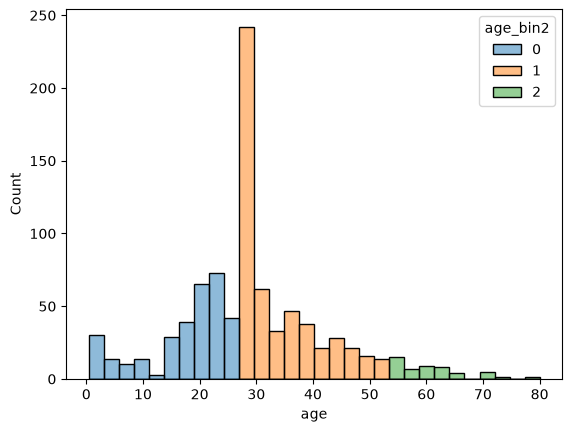

In [ ]:
# HistoPlot
sns.histplot(df, x='age', hue = 'age_bin2')

<h5 style="color:Blue; font-weight:bold">More Customize</h5>

In [13]:
# Define the Bins
bins = [0, 10, 18, 30, 50, 80]
labels = ['child', 'teenager', 'young adult', 'adult', 'elder']

In [14]:
# Binning
df['age_bin3'] = pd.cut(df['age'], bins=bins, labels=labels)

<Axes: xlabel='age', ylabel='Count'>

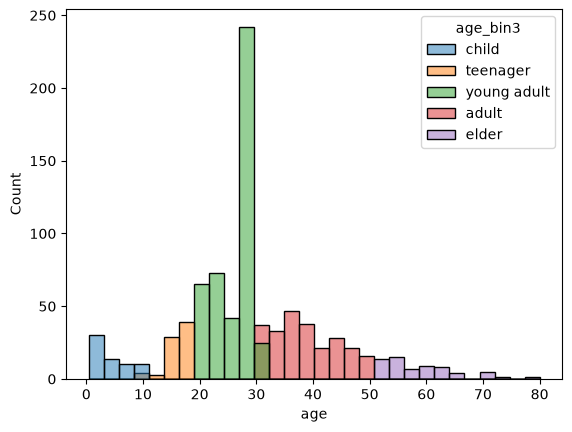

In [15]:
# HistoPLot
sns.histplot(df, x='age', hue='age_bin3')

---
<h3 style="color:orange; font-weight:bold">🤖 Automatic Binning</h3>

- **Automatic Binning = Automatically divides continuous values into bins.**
- You only specify the **number of bins**; the algorithm determines the boundaries.
- **KBinsDiscretizer** is a Scikit-learn tool used for automatic binning.

### Example

Values:

`10, 20, 30, 40, 50, 60`

If `n_bins = 3`:

`10, 20` → **Bin 1**  
`30, 40` → **Bin 2**  
`50, 60` → **Bin 3**

> 💡 **Rule:** Automatic Binning → **You choose the number of bins → Algorithm creates the groups.**

In [17]:
# Import Liberary
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import KBinsDiscretizer

In [18]:
# Load Dataset
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [19]:
# Impute Missing Values
df['age'] = df['age'].fillna(df['age'].median())
df['fare'] = df['fare'].fillna(df['fare'].median())

<Axes: xlabel='age', ylabel='Count'>

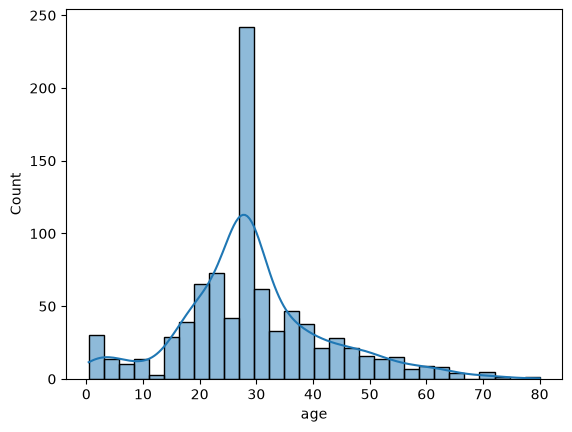

In [20]:
sns.histplot(df['age'], kde=True)

In [28]:
# 'Age' Column = Discretization
age_discretizer = KBinsDiscretizer(n_bins=3, encode='ordinal')  # Here you can Change 'Encoder Type'
age_discretizer = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='quantile')  ## Also Use 'kmeans', 'Uniform'

In [ ]:
# Run Dicretization Model
df['age_bin'] = age_discretizer.fit_transform(df[['age']])

<Axes: xlabel='age', ylabel='Count'>

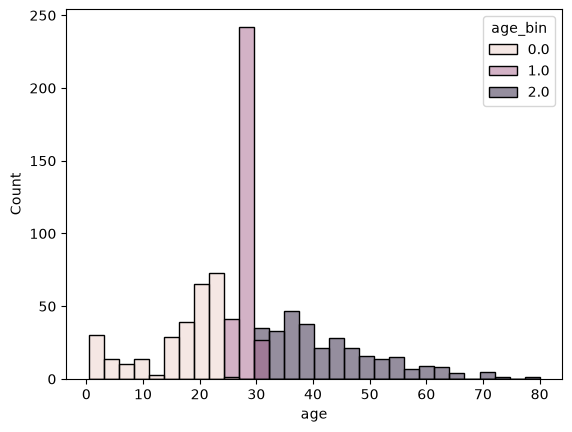

In [ ]:
# HistoPlot
sns.histplot(df, x='age', hue = 'age_bin')

---
## 🎯 Data Discretization — Final Takeaway

### 🔑 What We Practiced

- 📦 Created **custom bins manually**
- 🤖 Applied **Automatic Binning**
- ⚙️ Used **KBinsDiscretizer**
- 📊 Converted continuous values into meaningful groups
- 🔍 Compared different binning approaches

> 💡 **Final Rule:** Choose **Manual Binning** when you know meaningful boundaries; use **Automatic Binning** when you want the algorithm to create them.